In [1]:
#SCALAR GAUSS BONNET MODIFIED EXAMPLE

# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/SGB_NOBR/source')

from initialdata.bhinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

In [3]:
# Set up the chosen matter class
#scalar_mu = 1.0
scalar_mu = 0 # in the EsGB case
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 96.0 # outer edge of the grid (including ghosts)
#min_dr = 1 / 16 # roughly 32 points across the BH

min_dr = 1/16
#min_dr = 1 / 64
max_dr = 2

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}


In [4]:
initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

(-0.1, 0.1)

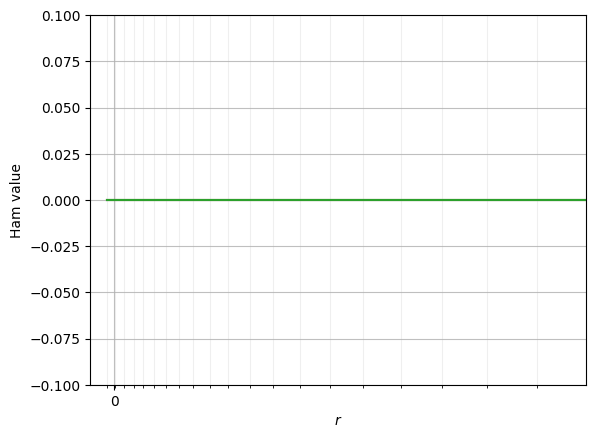

In [5]:
# check the Hamiltonian and momentum constraints are initially satisfied
Ham, Mom = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter)

# plot the profile for Ham
#plt.plot(r, Ham[0])
plt.plot(r, Mom[0])

plt.xlabel('r')
plt.ylabel('Ham value')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.5,10)
plt.ylim(-0.1,0.1)

In [6]:
# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)

# Get initial state
initial_state_HR = get_initial_state(grid_HR, background_HR)

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 275}


In [7]:
# find the apparent horizon for a given set of states
omega, ah_radius, bh_mass = get_horizon_diagnostics(initial_state, np.array([0]), grid, background, my_matter)

print("horizon is at r =", round(ah_radius[0],1))
print("horizon is at r =", ah_radius[0])

horizon is at r = 0.5
horizon is at r = 0.498678538330956


# Start running the simulation

In [8]:
# for control of time integrator and spatial grid
#T = 10 # Maximum evolution time
T = 25
#num_points_t = 128 # time resolution (only for outputs, not for integration, which is decided by python)
num_points_t = 250

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requested
solution = dense_solution.sol(t).T

  0%|          | 0/1000 [00:00<?, ?‰/s]

TraceFree_M_LL [[[-2.71881767e-15  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  3.29456024e-17  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  3.29456024e-17]]

 [[ 2.39484705e-14  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00 -1.04010055e-16  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00 -1.04010055e-16]]

 [[ 4.47263005e-14  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00 -2.15355144e-17  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00 -2.15355144e-17]]

 ...

 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]]
TraceFree_M_LL [[[-3.59979678e-

KeyboardInterrupt: 

# Evolution of scalar field 

In [24]:
inta = 0
for i in range(len(my_state_vector.VARIABLE_NAMES)):
    print('Index: ', inta, 'Variable Name: ',  my_state_vector.VARIABLE_NAMES[i])
    inta = inta +1

Index:  0 Variable Name:  phi
Index:  1 Variable Name:  hrr
Index:  2 Variable Name:  htt
Index:  3 Variable Name:  hpp
Index:  4 Variable Name:  K
Index:  5 Variable Name:  arr
Index:  6 Variable Name:  att
Index:  7 Variable Name:  app
Index:  8 Variable Name:  lambdar
Index:  9 Variable Name:  shiftr
Index:  10 Variable Name:  br
Index:  11 Variable Name:  lapse
Index:  12 Variable Name:  u
Index:  13 Variable Name:  v


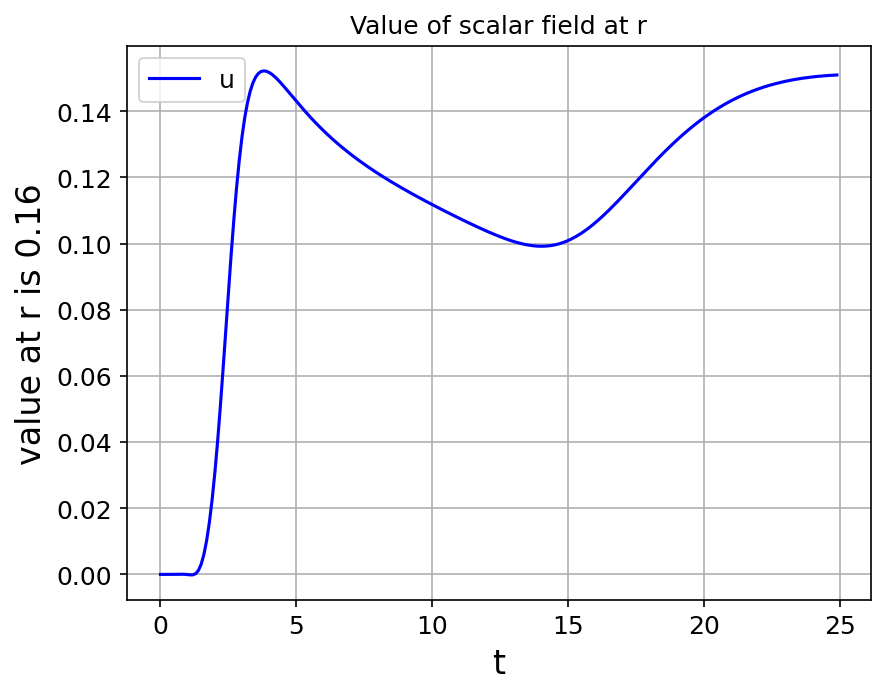

In [25]:
# Plot a single point versus time
idx_u = 12

var1 = idx_u

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.title("Value of scalar field at r")
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

# Evolution of variables (lapse, shift, K, Conformal factor, ...)

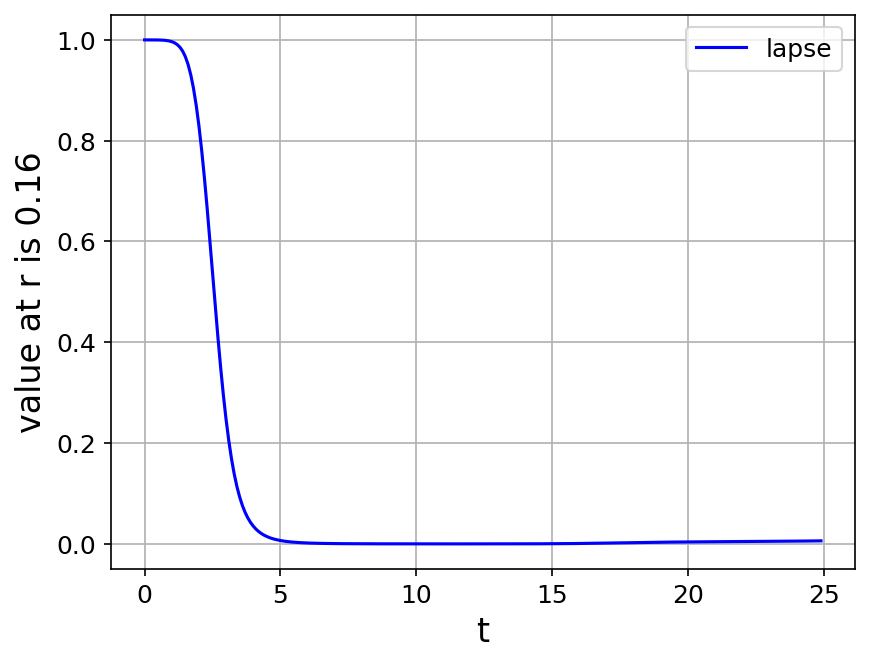

In [26]:
# Plot a single point versus time
idx_u = 11

var1 = 11

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

## Different variables at different radii and different times

## Conformal factor

(-0.1, 0.1)

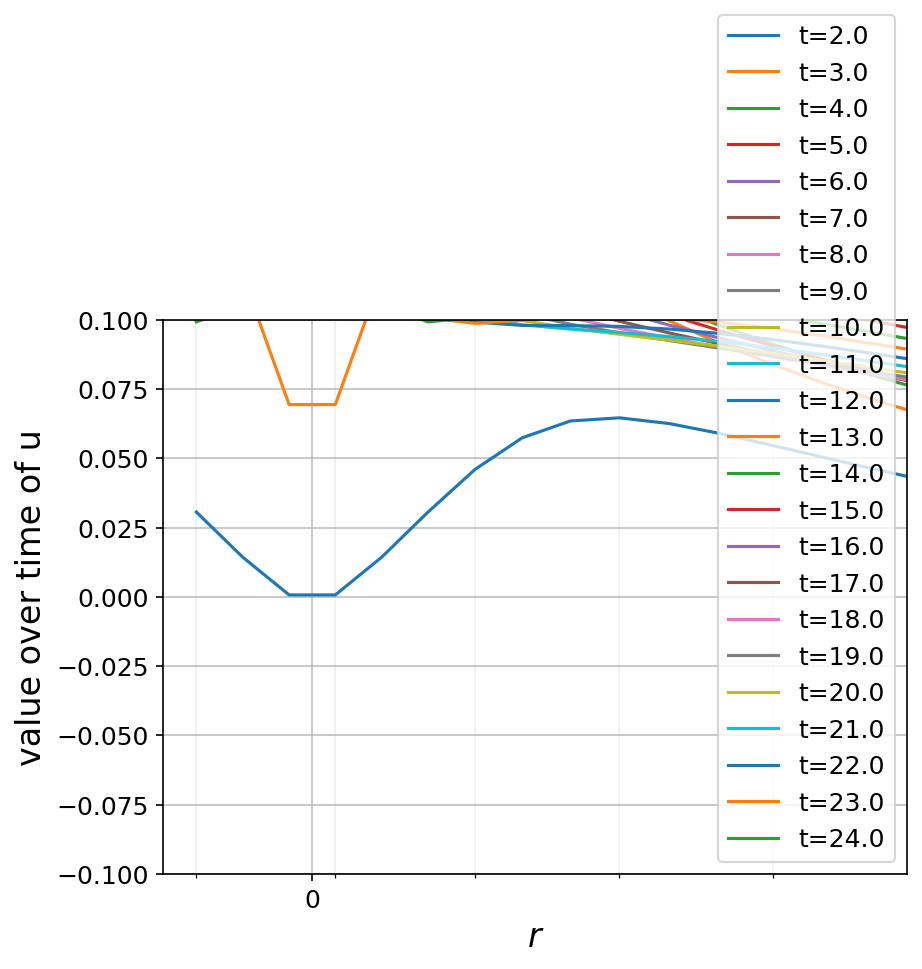

In [27]:
# i is the index of time 
# t_i is the corresponding timie value to that index

# if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
    # i< 100: times before the 100the time point (only the index of the time)
    # (i % 10 == 0) : every 10th point, avoids to many lines.
    # (t_i > 9.0) : the actual value of the time must be greater than 9 


iii = 10
var = 12
for i, t_i in enumerate(t) :
    if (i < 1000) and (i % 10 == 0) and (t_i > 1.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])

ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.2,0.8)
plt.ylim(-0.1,0.1)



# Evolution of different parameters in function of $r$ at $t=0$

Actual AH:  0.498678538330956
Effective AH:  0.47993604100070275
phi at AH:  0.06252766417263976
chi0:  0.7787146083221396
Actual AH:  0.498678538330956
Effective AH:  0.47993604100070275
phi at AH:  0.09958217048246683
chi0:  0.6714413007669973


(0.0, 0.1)

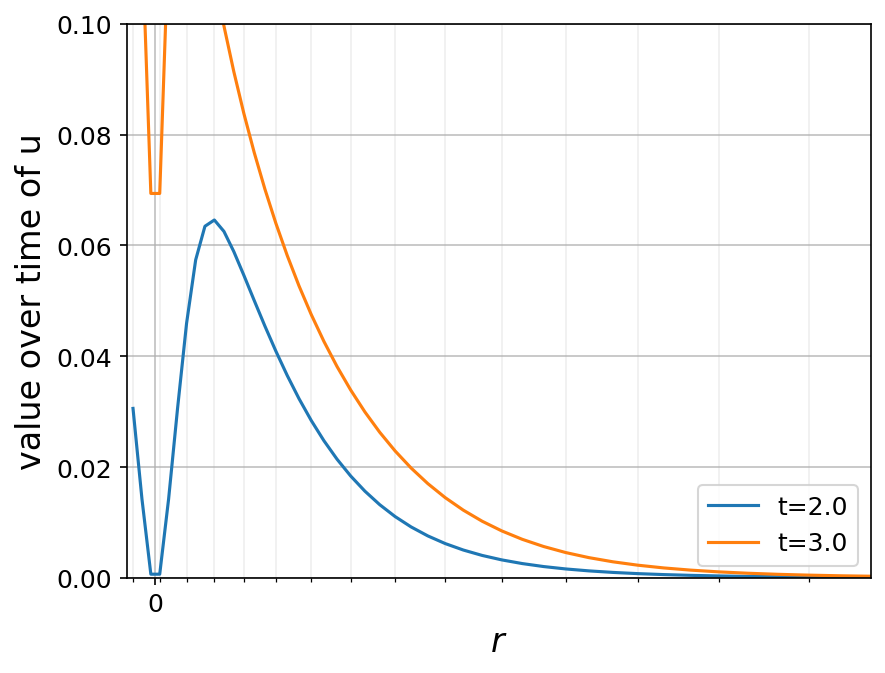

In [28]:
# i is the index of time 
# t_i is the corresponding timie value to that index

# if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
    # i< 100: times before the 100the time point (only the index of the time)
    # (i % 10 == 0) : every 10th point, avoids to many lines.
    # (t_i > 9.0) : the actual value of the time must be greater than 9 


iii = 10
var = 12
for i, t_i in enumerate(t) :
    if (i < 40) and (i % 10 == 0) and (t_i > 1.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        print('Actual AH: ', ah_radius[0])
        print('Effective AH: ', r[iii])
        print('phi at AH: ', f_t[iii])
        print('chi0: ',np.exp(-4*f_t[iii]))
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])

ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.2,5)
plt.ylim(0,0.1)



## Scalar Field

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(-1.0, 2.0)

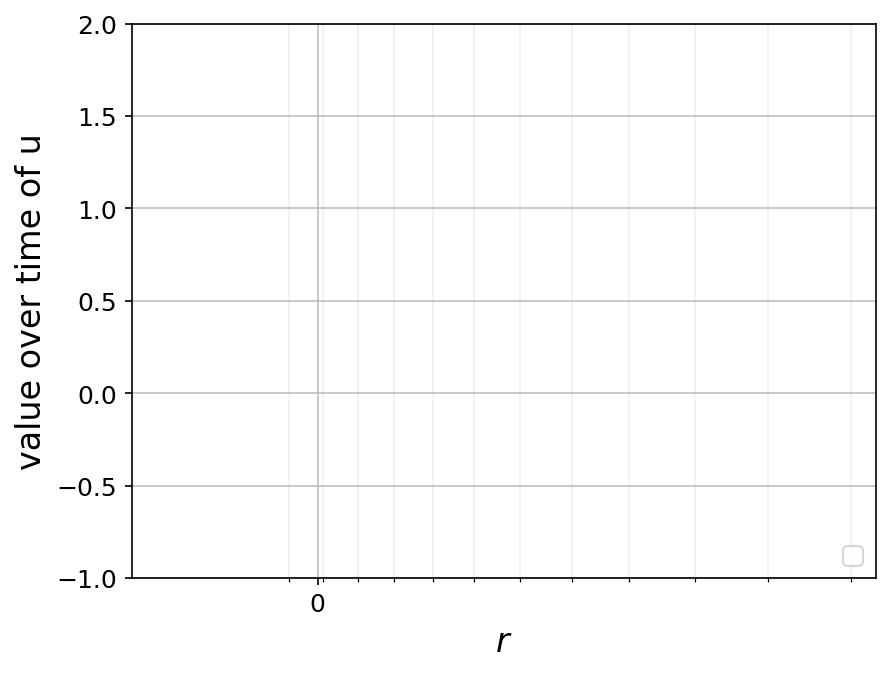

In [29]:
# i is the index of time 
# t_i is the corresponding timie value to that index

# if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
    # i< 100: times before the 100the time point (only the index of the time)
    # (i % 10 == 0) : every 10th point, avoids to many lines.
    # (t_i > 9.0) : the actual value of the time must be greater than 9 



var = 12
for i, t_i in enumerate(t) :
    if (i < 50) and (i % 1 == 0) and (t_i > 5.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])

ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-1,3)
plt.ylim(-1,2)


In [30]:
'''# calculate the diagnostics, just the Hamiltonian constraint for now
Ham, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)'''

'# calculate the diagnostics, just the Hamiltonian constraint for now\nHam, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)'

In [31]:
'''# plot the profile for Ham and Mom at a selection of times

for i, t_i in enumerate(t) :
    if (i < num_points_t) and (i % 30 == 0) :
        labelt = "t="+str(round(t_i,2))
        Ham_t = Ham[i,:]
        ax1 = plt.subplot(211)
        plt.plot(r, Ham_t, label=labelt)
        ax2 = plt.subplot(212)
        Mom_t = np.sqrt(Mom[i,:,i_r]**2 + Mom[i,:,i_t]**2 + Mom[i,:,i_p]**2)
        plt.plot(r, Mom_t, label=labelt)

plt.legend()
ax2.set_xlabel('r')
ax1.set_ylabel('Ham value over time')
ax1.set_xlim(-1,20.0)
ax1.set_ylim(-0.1,0.1)
ax1.grid()
ax2.set_ylabel('Mom_r value over time')
ax2.set_xlim(-1,20.0)
ax2.set_ylim(-0.1,0.1)
ax2.grid()'''

'# plot the profile for Ham and Mom at a selection of times\n\nfor i, t_i in enumerate(t) :\n    if (i < num_points_t) and (i % 30 == 0) :\n        labelt = "t="+str(round(t_i,2))\n        Ham_t = Ham[i,:]\n        ax1 = plt.subplot(211)\n        plt.plot(r, Ham_t, label=labelt)\n        ax2 = plt.subplot(212)\n        Mom_t = np.sqrt(Mom[i,:,i_r]**2 + Mom[i,:,i_t]**2 + Mom[i,:,i_p]**2)\n        plt.plot(r, Mom_t, label=labelt)\n\nplt.legend()\nax2.set_xlabel(\'r\')\nax1.set_ylabel(\'Ham value over time\')\nax1.set_xlim(-1,20.0)\nax1.set_ylim(-0.1,0.1)\nax1.grid()\nax2.set_ylabel(\'Mom_r value over time\')\nax2.set_xlim(-1,20.0)\nax2.set_ylim(-0.1,0.1)\nax2.grid()'

# AH finder

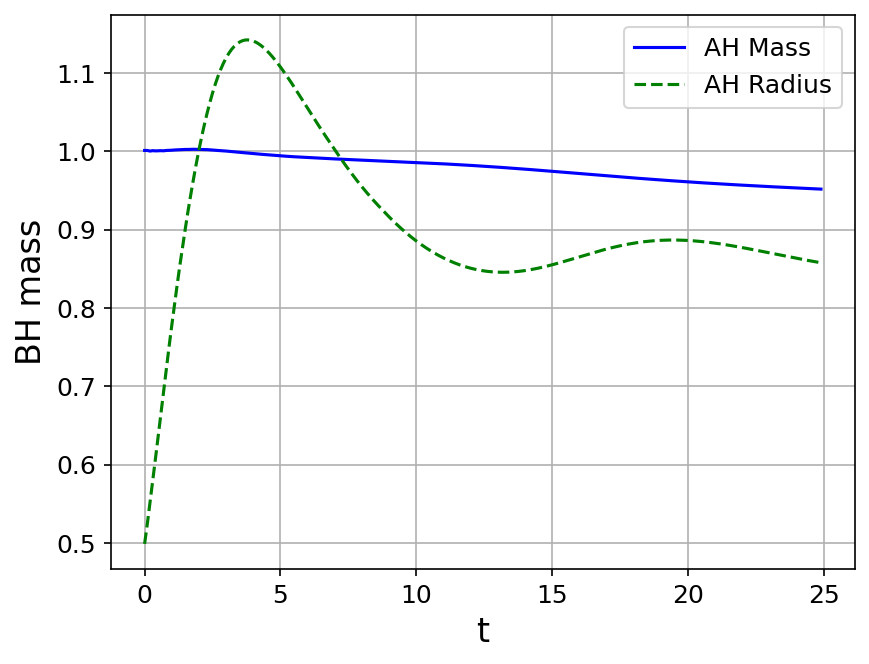

In [32]:
# Track the BH mass, show constant despite gauge evolution
omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)

plt.plot(t, bh_mass, 'b-', label="AH Mass")
plt.plot(t, ah_radius, 'g--', label="AH Radius")
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('BH mass')
plt.legend(loc='best')
#plt.ylim(-0.1,1.3)

#print('t: ', t)
#print('R_{AH}: ', ah_radius)
#print(len(ah_radius))


plt.grid()

# Scalar field evolution at AH

In [33]:
interpolated_u_of_r_at_different_times = []
var = 12

for timepoint in range(len(t)):
    interpolated_u_of_r_at_different_times.append(interp1d(r,solution[timepoint, var * num_points: (var + 1) * num_points],  kind='cubic'))
    


u_of_ahR = []

for idx_ahr, ahr in enumerate(ah_radius):
    u_of_ahR.append(interpolated_u_of_r_at_different_times[idx_ahr](ahr))


var = 12

#print(u_of_ahR)

final value of scalar field:  0.10575107211325303


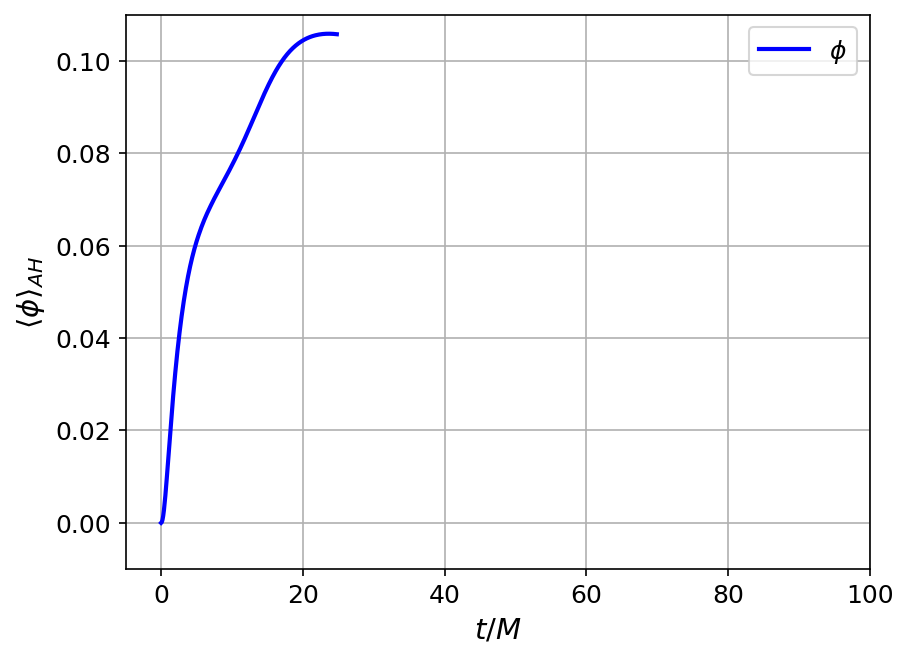

In [34]:
maxidx = 249

'''
tester = []
for i in range(len(u_of_ahR[:maxidx])):
    tester.append(3*np.pi*u_of_ahR[:maxidx][i])
'''

plt.plot(t[:maxidx], u_of_ahR[:maxidx], 'b-', label=r'$\phi$', linewidth=2)
#plt.plot(t[:maxidx], tester, 'b-', label='u')

plt.legend(loc='best')
plt.ylim(-0.01,0.11)
plt.xlim(-5,100)
plt.xlabel(r'$t/M$', fontsize=14)
plt.ylabel(r'$\langle \phi \rangle_{AH}$', fontsize=14)
plt.legend(loc='best')
plt.grid()

print('final value of scalar field: ', u_of_ahR[maxidx])
#plt.savefig('ScalarProfile')

### Higher quality 

final value of scalar field (last plotted point): 0.10576991338326404


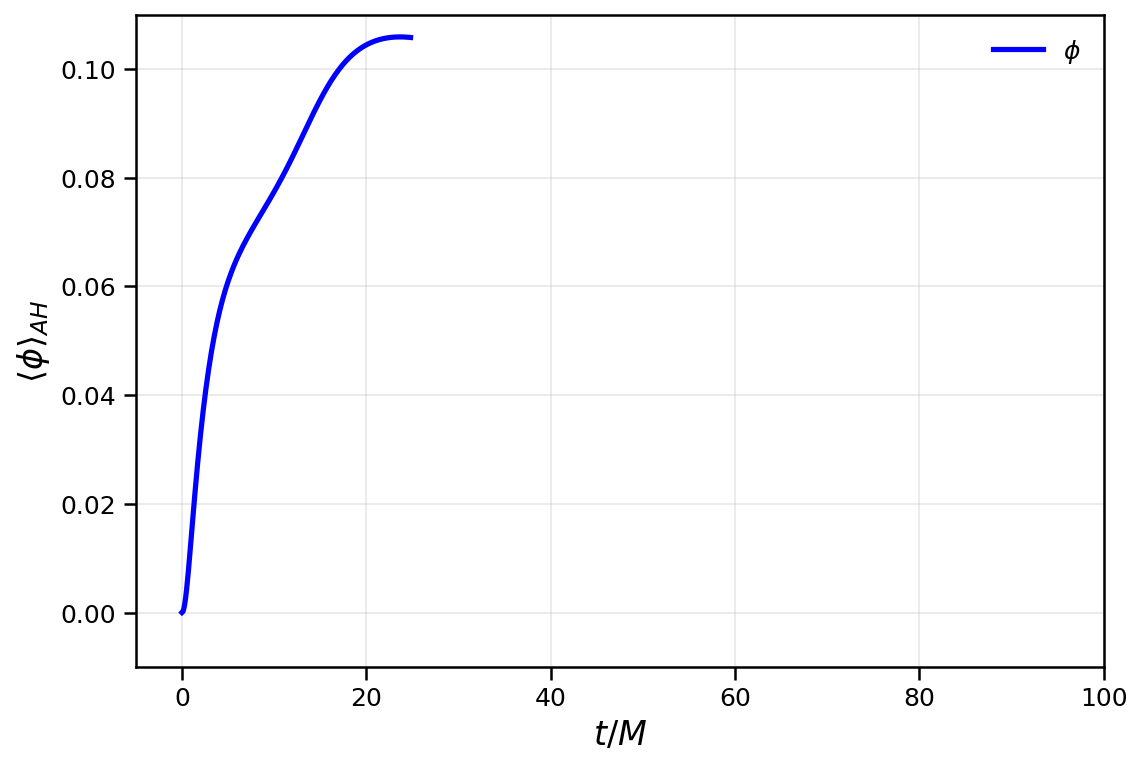

In [35]:
import matplotlib.pyplot as plt
import numpy as np

maxidx = 249  # will plot indices [0..248]; last plotted point is maxidx-1

plt.rcParams.update({
    "figure.dpi": 150,        # on-screen sharpness
    "savefig.dpi": 300,       # export resolution for PNG
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)  # bigger canvas
ax.plot(t[:maxidx], u_of_ahR[:maxidx], 'b-', lw=2.5, label=r'$\phi$')

ax.set_xlim(-5, 100)
ax.set_ylim(-0.01, 0.11)
ax.set_xlabel(r'$t/M$')
ax.set_ylabel(r'$\langle \phi \rangle_{AH}$')
ax.legend(frameon=False, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(width=1.2, length=6)
for s in ax.spines.values():
    s.set_linewidth(1.2)

print('final value of scalar field (last plotted point):', u_of_ahR[maxidx-1])

# High-quality exports:
#fig.savefig('ScalarProfile.pdf', bbox_inches='tight')   # vector, infinite zoom
#fig.savefig('ScalarProfile.png', dpi=300, bbox_inches='tight')  # crisp raster
# fig.savefig('ScalarProfile.svg', bbox_inches='tight')  # alternative vector
plt.show()


# 
#

# Conformal factor at apparant horizon

In [36]:
var0 = 0

interpolated_phi_of_r_at_different_times = []

for timepoint in range(len(t)):
    interpolated_phi_of_r_at_different_times.append(interp1d(r,solution[timepoint, var0 * num_points: (var0 + 1) * num_points],  kind='quadratic', fill_value='extrapolate'))
    
# This is a list of all of the interpolation functions (function of value of u in terms value of r [gotten in an interpolated way]) at all the different time steps

In [37]:
phi_of_ahR = []

for idx_ahr, ahr in enumerate(ah_radius):
    phi_of_ahR.append(interpolated_phi_of_r_at_different_times[idx_ahr](ahr))
    
#print(u_of_ahR)

initial value of chi:  0.19821717966099556


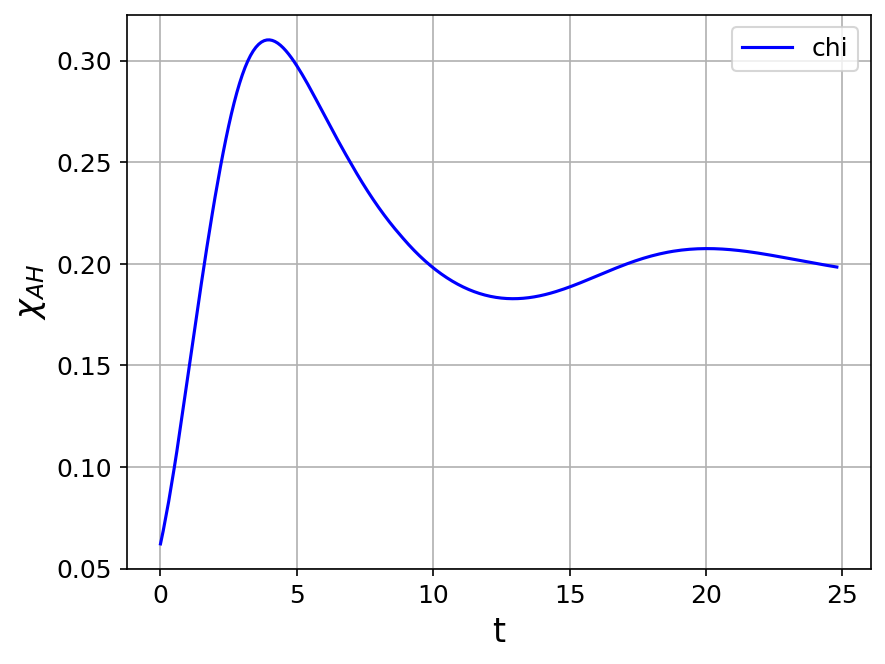

In [38]:
maxidx = 249

def chicalc(phi):
    return np.exp(-4*phi)

listofchi = []
for i in range(len(phi_of_ahR)):
    listofchi.append(chicalc(phi_of_ahR[i]))

plt.plot(t[:maxidx], listofchi[:maxidx], 'b-', label='chi')
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('$\chi_{AH}$')
plt.legend(loc='best')
plt.grid()

print('initial value of chi: ', listofchi[maxidx])

# Coupling function analysis

(0.0, 0.3)

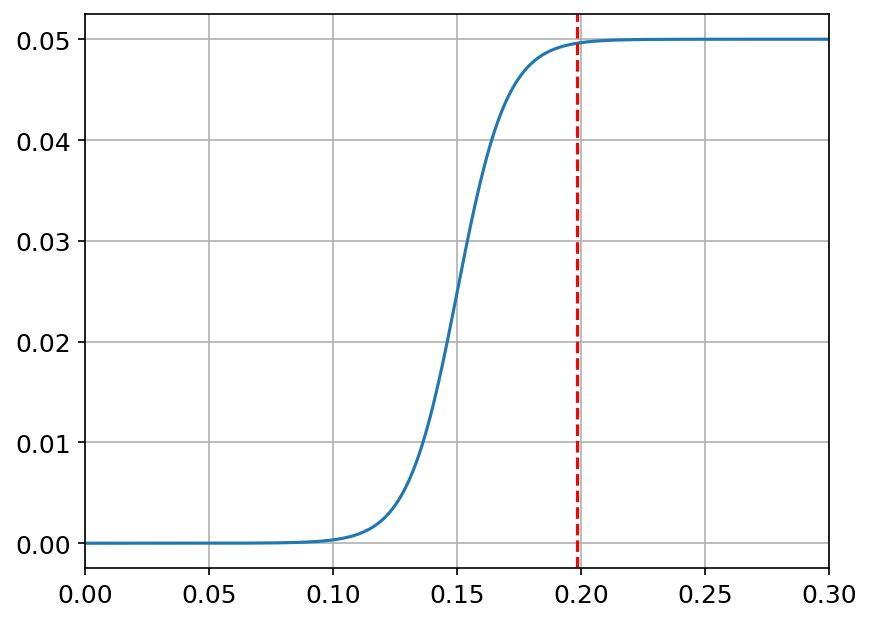

In [39]:
chi = np.linspace(0, 1, 1000)
chi0 = 0.15

def function_of_lambda(chi0, lambda_GB):
    return (lambda_GB)/(1+np.exp(-100*(chi-chi0)))

plt.plot(chi, function_of_lambda(chi0, 0.05))
plt.axvline(x=listofchi[maxidx], color='r', linestyle='--', label='MaxChi')

plt.grid()
plt.xlim(0,0.3)